# TP3 - Regresión

Se usa el dataset **California Housing** para predecir el precio de viviendas.

Se comparan dos modelos:
- Regresión lineal
- Regresión polinómica de grado 2

Se evalúan con:
- MSE
- R²

Primeras filas:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


Valores nulos:


MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64


--- Regresión lineal ---
MSE train: 0.5179331255246699
MSE test : 0.5558915986952444
R2 train : 0.6125511913966952
R2 test  : 0.5757877060324508

--- Regresión polinómica grado 2 ---
MSE train: 0.42072661515735815
MSE test : 0.4643015240316436
R2 train : 0.6852681982344936
R2 test  : 0.6456819727724054

Comparación:


,Modelo,MSE test,R2 test
0,Lineal,0.555892,0.575788
1,Polinómico,0.464302,0.645682


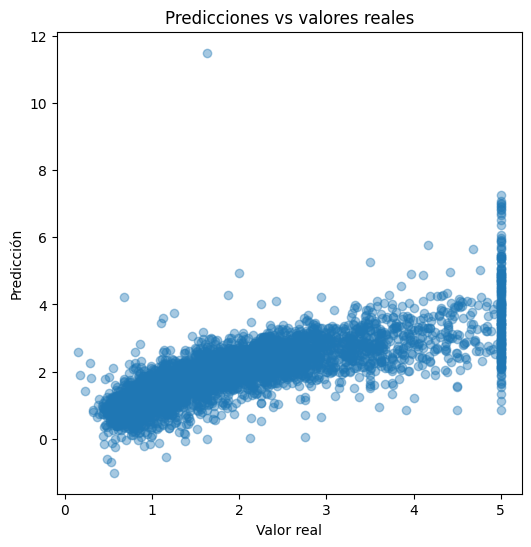


Feature con mayor impacto:


,Feature,Coeficiente,Abs
3,AveBedrms,0.783145,0.783145


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

# Cargar datos
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Primeras filas:")
display(X.head())

print("Valores nulos:")
display(X.isnull().sum())

# Dividir train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Modelo lineal
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train, y_train)

pred_train_lin = modelo_lineal.predict(X_train)
pred_test_lin = modelo_lineal.predict(X_test)

print("\n--- Regresión lineal ---")
print("MSE train:", mean_squared_error(y_train, pred_train_lin))
print("MSE test :", mean_squared_error(y_test, pred_test_lin))
print("R2 train :", r2_score(y_train, pred_train_lin))
print("R2 test  :", r2_score(y_test, pred_test_lin))

# Modelo polinómico grado 2
modelo_poly = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    LinearRegression()
)
modelo_poly.fit(X_train, y_train)

pred_train_poly = modelo_poly.predict(X_train)
pred_test_poly = modelo_poly.predict(X_test)

print("\n--- Regresión polinómica grado 2 ---")
print("MSE train:", mean_squared_error(y_train, pred_train_poly))
print("MSE test :", mean_squared_error(y_test, pred_test_poly))
print("R2 train :", r2_score(y_train, pred_train_poly))
print("R2 test  :", r2_score(y_test, pred_test_poly))

# Comparación
resultados = pd.DataFrame({
    "Modelo": ["Lineal", "Polinómico"],
    "MSE test": [
        mean_squared_error(y_test, pred_test_lin),
        mean_squared_error(y_test, pred_test_poly)
    ],
    "R2 test": [
        r2_score(y_test, pred_test_lin),
        r2_score(y_test, pred_test_poly)
    ]
})

print("\nComparación:")
display(resultados)

# Gráfico
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_test_lin, alpha=0.4)
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("Predicciones vs valores reales")
plt.show()

# Feature más importante
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coeficiente": modelo_lineal.coef_
})
coef["Abs"] = coef["Coeficiente"].abs()

print("\nFeature con mayor impacto:")
display(coef.sort_values("Abs", ascending=False).head(1))



## Respuestas

**¿Cuál modelo es mejor?**  
El modelo polinómico fue mejor porque en test obtuvo menor MSE (**0.4643**) y mayor R2 (**0.6457**) que el modelo lineal.

**¿Hay overfitting?**  
No se ve un overfitting fuerte. En el modelo polinómico el resultado de train es mejor que test, pero la diferencia no es exagerada.

**¿Qué feature tiene más impacto?**  
Según los coeficientes de la regresión lineal, la variable con mayor impacto fue **AveBedrms**, porque tuvo el coeficiente de mayor valor absoluto.